# Routing Model: Valid vs Invalid (Microscopic Blood Image Detector)

**Goal:** Binary classifier — `valid` (microscopic blood images) vs `invalid` (random natural images).

**Valid class** (~6800 images): Anemia (AneRBC) + Leukemia (mehradaria) + Malaria (iarunava) datasets.

**Invalid class**: All images from Natural Images dataset (airplane, car, cat, dog, flower, fruit, motorbike, person).

**Datasets to add (Add Input → Datasets):**
- `jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images`
- `mehradaria/leukemia`
- `iarunava/cell-images-for-detecting-malaria`
- `prasunroy/natural-images`

**Protections:**
- MD5 dedup before split
- Train/Val/Test split AFTER dedup (no leakage)
- Augmentation ONLY on train set
- Stratified split (equal class ratio in val/test)

In [1]:
# ============================================================
# CELL 1: Imports & Config
# ============================================================

import os, gc, json, shutil, random, hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib

# ---- Seeds ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Paths ----
BASE_INPUT  = Path('/kaggle/input')
WORK        = Path('/kaggle/working')
RAW_DIR     = WORK / 'routing_raw'
DATASET_DIR = WORK / 'routing_dataset'
ARTIFACT_DIR= WORK / 'routing_artifacts'
for d in [RAW_DIR, ARTIFACT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGE_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# ---- Hyperparams ----
VALID_PER_SOURCE   = 2267   # ~2267 x 3 sources = ~6800 valid total
INVALID_TOTAL      = 6899   # all natural images (~6899 available)
VAL_RATIO          = 0.15
TEST_RATIO         = 0.15
IMG_SIZE           = 224
BATCH_SIZE         = 32
EPOCHS             = 25
PATIENCE           = 5
LR                 = 3e-4
WEIGHT_DECAY       = 1e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# CELL 2: Discover & Verify Kaggle Input Paths
# ============================================================

print('=== Top-level input folders ===')
for p in sorted(BASE_INPUT.rglob('*')):
    if p.is_dir():
        # Count images inside
        imgs = [f for f in p.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXT]
        if imgs:
            print(f'  {p}  [{len(imgs)} images]')

print('\nDone scanning.')

=== Top-level input folders ===
  /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized  [13779 images]
  /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected  [13779 images]
  /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized  [13779 images]
  /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected  [13779 images]
  /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-I/Anemic_individuals/Binary_segmented  [500 images]
  /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-I/Anemic_i

In [3]:
# ============================================================
# CELL 3: Helper — collect images from a folder (recursive)
# ============================================================

def collect_images(folder: Path, limit: int = None) -> list:
    """Return sorted list of image paths from folder (recursive)."""
    paths = sorted([p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXT])
    if limit and len(paths) > limit:
        random.shuffle(paths)
        paths = paths[:limit]
    return paths


def md5(path: Path) -> str:
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()


def dedup(paths: list) -> list:
    """Remove duplicate images by MD5 hash."""
    seen = set()
    unique = []
    for p in paths:
        h = md5(p)
        if h not in seen:
            seen.add(h)
            unique.append(p)
    print(f'  Dedup: {len(paths)} → {len(unique)} unique')
    return unique


def stratified_split(paths, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO):
    """Split list into train/val/test with no overlap."""
    random.shuffle(paths)
    n = len(paths)
    n_test = int(n * test_ratio)
    n_val  = int(n * val_ratio)
    test   = paths[:n_test]
    val    = paths[n_test:n_test + n_val]
    train  = paths[n_test + n_val:]
    return train, val, test

print('Helpers defined.')

Helpers defined.


In [4]:
# ============================================================
# CELL 4: Build VALID image list (~6800 microscopic blood images)
# ============================================================

# ---- Anemia (AneRBC) ----
# Path: /kaggle/input/datasets/jocelyndumlao/anerbc-.../AneRBC_dataset/
# Contains: anemic/, non_anemic/  (or similar)
anemia_root = None
for p in BASE_INPUT.rglob('AneRBC_dataset'):
    if p.is_dir():
        anemia_root = p
        break
if anemia_root is None:
    # Fallback: find jocelyndumlao folder
    for p in BASE_INPUT.rglob('*jocelyndumlao*'):
        if p.is_dir():
            anemia_root = p
            break
print(f'Anemia root: {anemia_root}')

# ---- Leukemia (mehradaria) — use Original/ only (avoid train/test leakage from pre-split) ----
leukemia_root = None
for p in BASE_INPUT.rglob('leukemia'):
    if p.is_dir():
        leukemia_root = p
        break
print(f'Leukemia root: {leukemia_root}')

# ---- Malaria (iarunava) — use Parasitized + Uninfected both as 'valid' (they are blood cell images) ----
malaria_root = None
for p in BASE_INPUT.rglob('cell_images'):
    # Pick the top-level one (avoid nested duplicate)
    if p.is_dir() and p.parent.name != 'cell_images':
        malaria_root = p
        break
print(f'Malaria root: {malaria_root}')

# ---- Natural Images (prasunroy) ----
natural_root = None
for p in BASE_INPUT.rglob('natural_images'):
    if p.is_dir():
        natural_root = p
        break
if natural_root is None:
    for p in BASE_INPUT.rglob('*natural*'):
        if p.is_dir():
            natural_root = p
            break
print(f'Natural root: {natural_root}')

Anemia root: /kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset
Leukemia root: /kaggle/input/datasets/mehradaria/leukemia
Malaria root: /kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images
Natural root: /kaggle/input/datasets/prasunroy/natural-images/natural_images


In [5]:
# ============================================================
# CELL 5: Collect + Dedup images per class
# ============================================================

print('=== Collecting VALID images ===')

anemia_imgs   = collect_images(anemia_root,   limit=VALID_PER_SOURCE)
leukemia_imgs = collect_images(leukemia_root / 'Original', limit=VALID_PER_SOURCE)
malaria_imgs  = collect_images(malaria_root,  limit=VALID_PER_SOURCE)

print(f'Raw anemia: {len(anemia_imgs)}')
print(f'Raw leukemia: {len(leukemia_imgs)}')
print(f'Raw malaria: {len(malaria_imgs)}')

print('\nDeduping valid...')
anemia_imgs   = dedup(anemia_imgs)
leukemia_imgs = dedup(leukemia_imgs)
malaria_imgs  = dedup(malaria_imgs)

valid_imgs = anemia_imgs + leukemia_imgs + malaria_imgs
print(f'\nTotal valid images: {len(valid_imgs)}')

print('\n=== Collecting INVALID images ===')
invalid_imgs_raw = collect_images(natural_root)
print(f'Raw natural: {len(invalid_imgs_raw)}')
invalid_imgs = dedup(invalid_imgs_raw)
print(f'Total invalid images: {len(invalid_imgs)}')

=== Collecting VALID images ===
Raw anemia: 2267
Raw leukemia: 2267
Raw malaria: 2267

Deduping valid...
  Dedup: 2267 → 2254 unique
  Dedup: 2267 → 2249 unique
  Dedup: 2267 → 2220 unique

Total valid images: 6723

=== Collecting INVALID images ===
Raw natural: 6899
  Dedup: 6899 → 6897 unique
Total invalid images: 6897


In [6]:
# ============================================================
# CELL 6: Stratified Train/Val/Test Split — NO LEAKAGE
# ============================================================

# Balance classes: min(valid, invalid) images per class
n_balance = min(len(valid_imgs), len(invalid_imgs))
random.shuffle(valid_imgs)
random.shuffle(invalid_imgs)
valid_imgs   = valid_imgs[:n_balance]
invalid_imgs = invalid_imgs[:n_balance]

print(f'Balanced: {n_balance} valid + {n_balance} invalid = {2*n_balance} total')

# Split each class independently (stratified)
v_train, v_val, v_test = stratified_split(valid_imgs)
i_train, i_val, i_test = stratified_split(invalid_imgs)

print(f'\nTrain: {len(v_train)} valid + {len(i_train)} invalid = {len(v_train)+len(i_train)}')
print(f'Val:   {len(v_val)} valid + {len(i_val)} invalid = {len(v_val)+len(i_val)}')
print(f'Test:  {len(v_test)} valid + {len(i_test)} invalid = {len(v_test)+len(i_test)}')

# Verify NO hash overlap between splits
print('\n=== Leakage check ===')
all_splits = {'train': v_train+i_train, 'val': v_val+i_val, 'test': v_test+i_test}
hashes = {split: set(md5(p) for p in paths) for split, paths in all_splits.items()}
print(f'  train ∩ val:  {len(hashes["train"] & hashes["val"])} overlaps')
print(f'  train ∩ test: {len(hashes["train"] & hashes["test"])} overlaps')
print(f'  val ∩ test:   {len(hashes["val"] & hashes["test"])} overlaps')
print('PASS — zero overlap!' if not any([hashes['train']&hashes['val'], 
                                          hashes['train']&hashes['test'],
                                          hashes['val']&hashes['test']]) else 'FAIL — leakage detected!')

Balanced: 6723 valid + 6723 invalid = 13446 total

Train: 4707 valid + 4707 invalid = 9414
Val:   1008 valid + 1008 invalid = 2016
Test:  1008 valid + 1008 invalid = 2016

=== Leakage check ===
  train ∩ val:  0 overlaps
  train ∩ test: 0 overlaps
  val ∩ test:   0 overlaps
PASS — zero overlap!


In [7]:
# ============================================================
# CELL 7: Copy images into folder structure
# routing_dataset/
#   train/valid/  train/invalid/
#   val/valid/    val/invalid/
#   test/valid/   test/invalid/
# ============================================================

def copy_images(img_list, dest_folder: Path, label: str):
    dest = dest_folder / label
    dest.mkdir(parents=True, exist_ok=True)
    for src in img_list:
        shutil.copy2(src, dest / src.name)
    print(f'  Copied {len(img_list)} → {dest}')

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

print('Building dataset folder...')
copy_images(v_train, DATASET_DIR/'train', 'valid')
copy_images(i_train, DATASET_DIR/'train', 'invalid')
copy_images(v_val,   DATASET_DIR/'val',   'valid')
copy_images(i_val,   DATASET_DIR/'val',   'invalid')
copy_images(v_test,  DATASET_DIR/'test',  'valid')
copy_images(i_test,  DATASET_DIR/'test',  'invalid')
print('Done!')

Building dataset folder...
  Copied 4707 → /kaggle/working/routing_dataset/train/valid
  Copied 4707 → /kaggle/working/routing_dataset/train/invalid
  Copied 1008 → /kaggle/working/routing_dataset/val/valid
  Copied 1008 → /kaggle/working/routing_dataset/val/invalid
  Copied 1008 → /kaggle/working/routing_dataset/test/valid
  Copied 1008 → /kaggle/working/routing_dataset/test/invalid
Done!


In [8]:
# ============================================================
# CELL 8: DataLoaders with Augmentation (train-only)
# ============================================================

MEAN = [0.485, 0.456, 0.406]   # ImageNet stats work well as starting point
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(DATASET_DIR / 'train', transform=train_tf)
val_ds   = datasets.ImageFolder(DATASET_DIR / 'val',   transform=eval_tf)
test_ds  = datasets.ImageFolder(DATASET_DIR / 'test',  transform=eval_tf)

print('Classes:', train_ds.classes)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

# Weighted sampler to handle any residual imbalance
class_counts = np.array([train_ds.targets.count(i) for i in range(len(train_ds.classes))])
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,   num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Classes: ['invalid', 'valid']
Train: 9350  Val: 2009  Test: 2013


In [9]:
# ============================================================
# CELL 9: Custom CNN Architecture (RoutingCNN)
# Design goals:
#   - Lightweight but powerful for binary routing
#   - Depthwise separable convolutions for efficiency
#   - Squeeze-and-Excite attention in each block
#   - Batch Norm + Dropout for regularization
# ============================================================

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class DSConvBlock(nn.Module):
    """Depthwise-Separable Conv + BN + ReLU + SE."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.ReLU6(inplace=True),
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU6(inplace=True),
        )
        self.se = SEBlock(out_ch)

    def forward(self, x):
        return self.se(self.pw(self.dw(x)))


class ResidualDSBlock(nn.Module):
    """DSConv block with residual connection when in_ch == out_ch."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = DSConvBlock(in_ch, out_ch, stride)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)


class RoutingCNN(nn.Module):
    """
    Custom lightweight CNN for microscopic image routing.
    Input: 3 x 224 x 224
    Output: 2 (valid / invalid)
    
    Architecture:
      Stem: 3 → 32  (7x7, stride 2)     → 112x112
      Block1: 32 → 64  (stride 2)        →  56x56
      Block2: 64 → 128 (stride 2) x2     →  28x28
      Block3: 128→ 256 (stride 2) x2     →  14x14
      Block4: 256→ 512 (stride 2) x2     →   7x7
      GAP → FC(512→256) → Dropout → FC(256→2)
    """
    def __init__(self, num_classes=2, drop=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),  # → 56x56
        )
        self.block1 = ResidualDSBlock(32, 64, stride=1)
        self.block2 = nn.Sequential(
            ResidualDSBlock(64, 128, stride=2),
            ResidualDSBlock(128, 128, stride=1),
        )
        self.block3 = nn.Sequential(
            ResidualDSBlock(128, 256, stride=2),
            ResidualDSBlock(256, 256, stride=1),
        )
        self.block4 = nn.Sequential(
            ResidualDSBlock(256, 512, stride=2),
            ResidualDSBlock(512, 512, stride=1),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(drop),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.head(x)


model = RoutingCNN(num_classes=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'RoutingCNN params: {total_params:,}')
print(model)

RoutingCNN params: 938,102
RoutingCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (block1): ResidualDSBlock(
    (block): DSConvBlock(
      (dw): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (pw): Sequential(
        (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (se): SEBlock(
        (se): Sequential(
          (0): AdaptiveAvgPool2d(output_size=1)
    

In [10]:
# ============================================================
# CELL 10: Training Setup
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def evaluate(loader, model):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return loss_sum / total, correct / total, all_preds, all_labels

print('Training setup done.')

Training setup done.


In [11]:
# ============================================================
# CELL 11: Training Loop
# ============================================================

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
patience_counter = 0
best_model_path = ARTIFACT_DIR / 'routing_cnn_best.pth'

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss    += loss.item() * imgs.size(0)
        train_correct += (out.argmax(1) == labels).sum().item()
        train_total   += imgs.size(0)

    scheduler.step()

    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss, v_acc, _, _ = evaluate(val_loader, model)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f'Epoch [{epoch:02d}/{EPOCHS}] '
          f'Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | '
          f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} | '
          f'LR: {scheduler.get_last_lr()[0]:.2e}')

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val_acc={v_acc:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

print(f'\nBest Val Acc: {best_val_acc:.4f}')

Epoch [01/25] Train Loss: 0.1936 Acc: 0.9660 | Val Loss: 0.1944 Acc: 0.9796 | LR: 2.99e-04
  ✓ Best model saved (val_acc=0.9796)
Epoch [02/25] Train Loss: 0.1379 Acc: 0.9940 | Val Loss: 0.1236 Acc: 0.9990 | LR: 2.95e-04
  ✓ Best model saved (val_acc=0.9990)
Epoch [03/25] Train Loss: 0.1287 Acc: 0.9969 | Val Loss: 0.1194 Acc: 0.9985 | LR: 2.90e-04
Epoch [04/25] Train Loss: 0.1284 Acc: 0.9964 | Val Loss: 0.1193 Acc: 0.9995 | LR: 2.82e-04
  ✓ Best model saved (val_acc=0.9995)
Epoch [05/25] Train Loss: 0.1274 Acc: 0.9967 | Val Loss: 0.1185 Acc: 1.0000 | LR: 2.71e-04
  ✓ Best model saved (val_acc=1.0000)
Epoch [06/25] Train Loss: 0.1276 Acc: 0.9963 | Val Loss: 0.1183 Acc: 1.0000 | LR: 2.59e-04
Epoch [07/25] Train Loss: 0.1247 Acc: 0.9976 | Val Loss: 0.1212 Acc: 0.9990 | LR: 2.46e-04
Epoch [08/25] Train Loss: 0.1215 Acc: 0.9990 | Val Loss: 0.1174 Acc: 1.0000 | LR: 2.31e-04
Epoch [09/25] Train Loss: 0.1217 Acc: 0.9990 | Val Loss: 0.1181 Acc: 1.0000 | LR: 2.14e-04
Epoch [10/25] Train Loss: 0.1

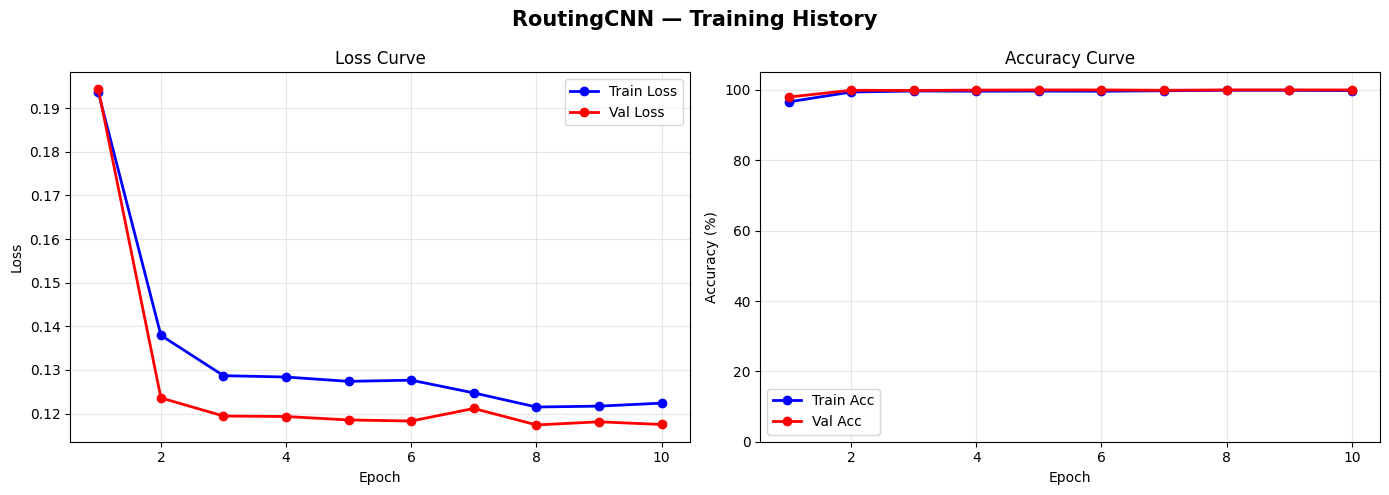

Saved: training_history.png


In [12]:
# ============================================================
# CELL 12: Visualize — Train vs Val (Loss & Accuracy)
# ============================================================

epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoutingCNN — Training History', fontsize=15, fontweight='bold')

# Loss
axes[0].plot(ep_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(ep_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(ep_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(ep_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_history.png')

In [13]:
# ============================================================
# CELL 13: Evaluate on Test Set + Confusion Matrix
# ============================================================

# Load best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_loss, test_acc, test_preds, test_labels = evaluate(test_loader, model)
class_names = test_ds.classes  # ['invalid', 'valid'] — alphabetical

print(f'Test Loss: {test_loss:.4f}  |  Test Acc: {test_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=class_names))

Test Loss: 0.1195  |  Test Acc: 99.95%

Classification Report:
              precision    recall  f1-score   support

     invalid       1.00      1.00      1.00      1008
       valid       1.00      1.00      1.00      1005

    accuracy                           1.00      2013
   macro avg       1.00      1.00      1.00      2013
weighted avg       1.00      1.00      1.00      2013



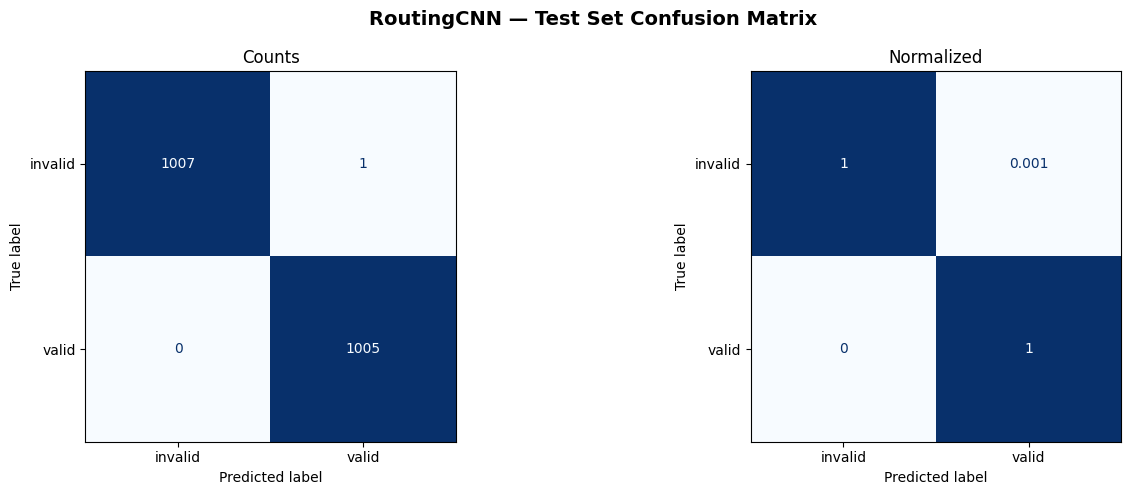

Saved: confusion_matrix.png


In [14]:
# ============================================================
# CELL 14: Confusion Matrix Plot
# ============================================================

cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RoutingCNN — Test Set Confusion Matrix', fontsize=14, fontweight='bold')

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Counts')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=np.round(cm_norm, 3), display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalized')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

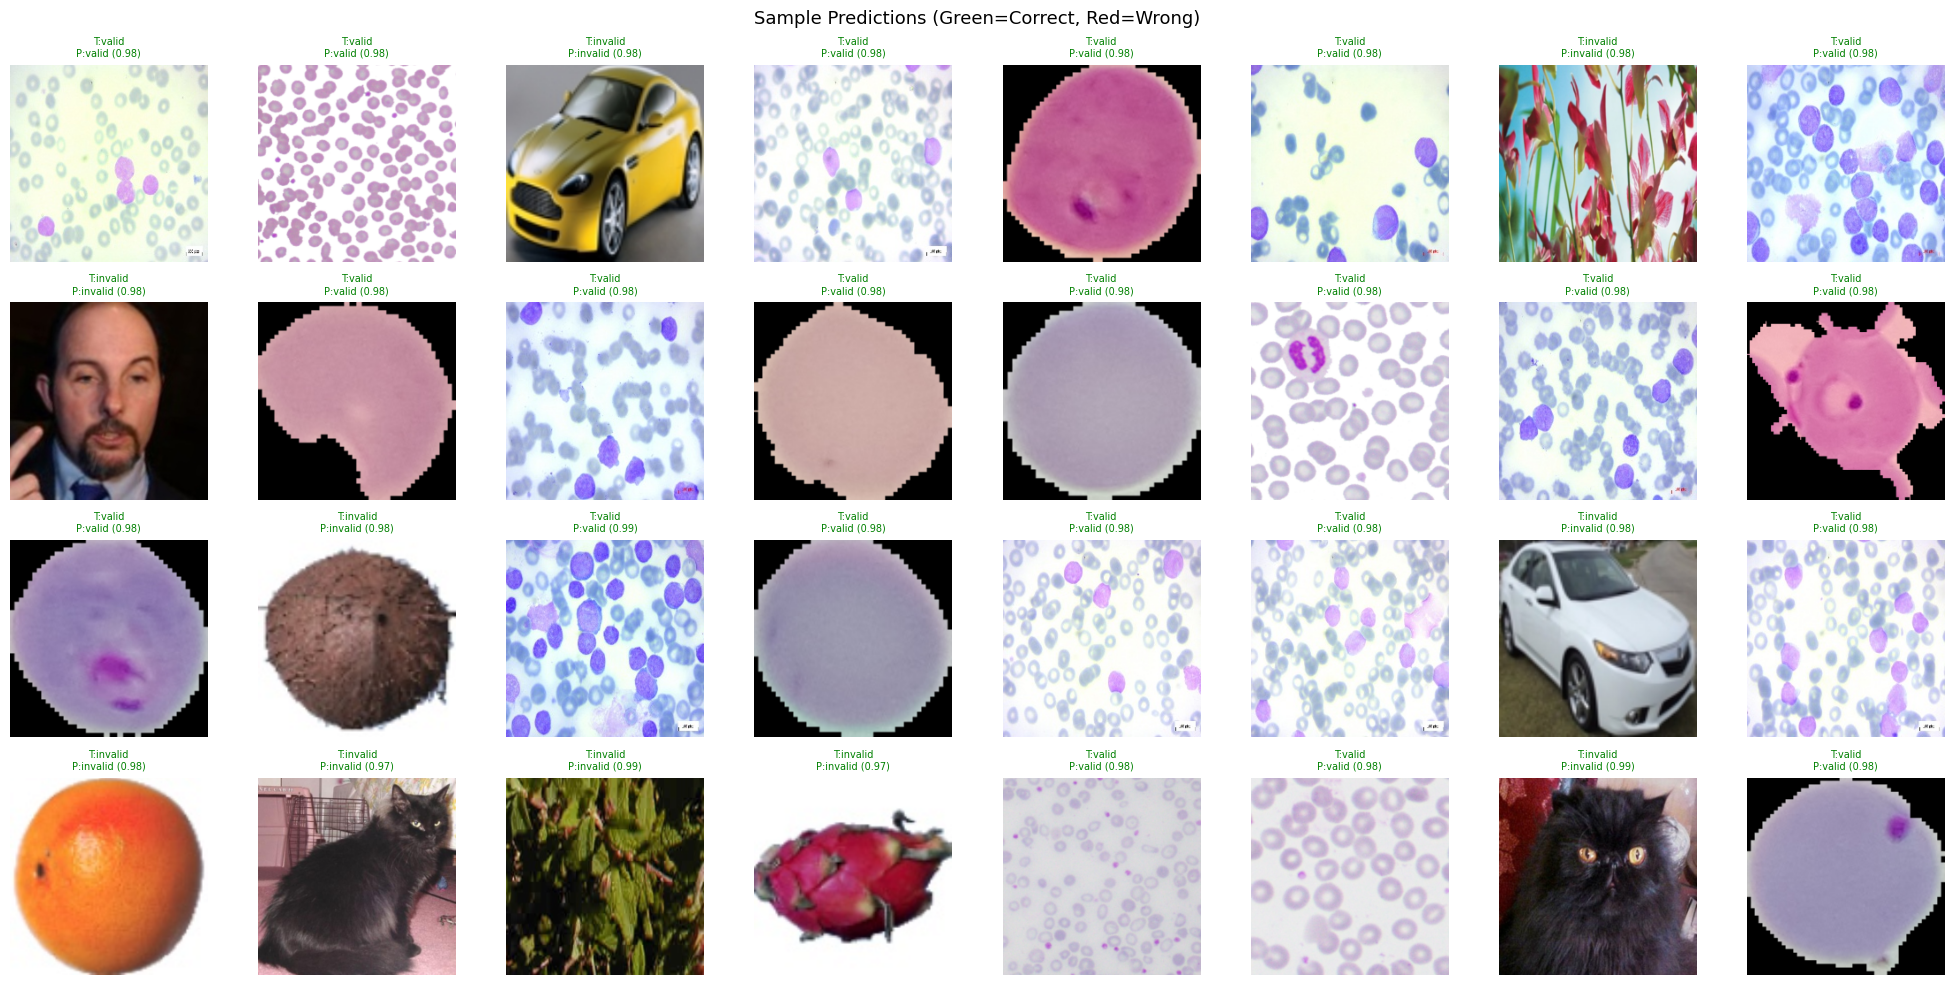

Saved: sample_predictions.png


In [18]:
# ============================================================
# CELL 15: Sample Predictions Visualization (Randomly Picked)
# ============================================================

def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

model.eval()

# Pick 32 completely random indices across the entire test dataset
num_samples = 32
random_indices = random.sample(range(len(test_ds)), num_samples)

# Gather and stack the random samples into a batch
imgs_list = []
labels_list = []
for idx in random_indices:
    img_t, label_t = test_ds[idx]
    imgs_list.append(img_t)
    labels_list.append(label_t)

imgs_batch = torch.stack(imgs_list)
labels_batch = torch.tensor(labels_list)

# Run inference
with torch.no_grad():
    logits = model(imgs_batch.to(device))
    probs  = torch.softmax(logits, dim=1).cpu()
    preds  = probs.argmax(dim=1)

# Plotting
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs_batch): 
        ax.axis('off')
        continue
    img  = denormalize(imgs_batch[i]).permute(1, 2, 0).numpy()
    true = class_names[labels_batch[i]]
    pred = class_names[preds[i]]
    conf = probs[i][preds[i]].item()
    color = 'green' if true == pred else 'red'
    ax.imshow(img)
    ax.set_title(f'T:{true}\nP:{pred} ({conf:.2f})', fontsize=7, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'sample_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: sample_predictions.png')

In [16]:
# ============================================================
# CELL 16: Save Final Model + Metadata
# ============================================================

# Save TorchScript version (for inference without class definition)
model.eval()
scripted = torch.jit.trace(model, torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device))
scripted.save(str(ARTIFACT_DIR / 'routing_cnn_scripted.pt'))

# Save metadata
metadata = {
    'model_name': 'RoutingCNN',
    'task': 'binary — valid (microscopic blood) vs invalid (natural images)',
    'classes': class_names,
    'valid_class_index': class_names.index('valid'),
    'invalid_class_index': class_names.index('invalid'),
    'img_size': IMG_SIZE,
    'normalize_mean': MEAN,
    'normalize_std': STD,
    'total_params': total_params,
    'test_accuracy': round(test_acc, 4),
    'best_val_accuracy': round(best_val_acc, 4),
    'epochs_trained': epochs_ran,
}

with open(ARTIFACT_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('=== SAVED ARTIFACTS ===')
for f in sorted(ARTIFACT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name}  ({size_mb:.1f} MB)')

print('\n✓ Training complete!')
print(f'  Best Val Acc : {best_val_acc*100:.2f}%')
print(f'  Test Acc     : {test_acc*100:.2f}%')
print(f'\nDownload routing_cnn_best.pth or routing_cnn_scripted.pt from Output tab.')

=== SAVED ARTIFACTS ===
  confusion_matrix.png  (0.0 MB)
  metadata.json  (0.0 MB)
  routing_cnn_best.pth  (3.8 MB)
  routing_cnn_scripted.pt  (4.1 MB)
  sample_predictions.png  (2.5 MB)
  training_history.png  (0.1 MB)

✓ Training complete!
  Best Val Acc : 100.00%
  Test Acc     : 99.95%

Download routing_cnn_best.pth or routing_cnn_scripted.pt from Output tab.


## Inference Example

```python
import torch
from torchvision import transforms
from PIL import Image

# Load scripted model (no class definition needed)
model = torch.jit.load('routing_cnn_scripted.pt').eval()

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

img = tf(Image.open('your_image.jpg').convert('RGB')).unsqueeze(0)
with torch.no_grad():
    probs = torch.softmax(model(img), dim=1)[0]
    # classes are alphabetical: [0]=invalid, [1]=valid
    print('valid' if probs[1] > 0.5 else 'invalid', f'({probs.max():.2%} confidence)')
```